In [2]:
import numpy as np
import pandas as pd
import importlib
import matplotlib.pyplot as plt

from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from matplotlib.ticker import MultipleLocator
from pathlib import Path
from scipy.integrate import simpson

import src.statistics.spline as spline
import src.analysis.plots as plots
import src.statistics.combination as comb
import src.statistics.corrfiles as cf

ROOT = cf.get_base_dir()

In [3]:
bins_hsc = np.arange(0.3, 1.8, 0.3)

markers = ["x", "s", "^", "D"]
linestyles = ["-", "--", "-.", ":"]
colormaps = [plt.get_cmap(c) for c in ["Reds", "Blues", "Greens", "Purples"]]
colors = [cmap(0.8) for cmap in colormaps]
tracers = ["BGS_ANY", "LRG", "ELGnotqso", "QSO"]
tracer_trad = {
    "BGS_ANY": "BGS",
    "LRG": "LRG",
    "ELGnotqso": "ELG",
    "QSO": "QSO",
}

PAPER_FIGURES_ROOT = Path(
    "/global/cfs/projectdirs/desi/users/jchdj/desi-y3-hsc/paper/figures/"
)
if not PAPER_FIGURES_ROOT.exists():
    PAPER_FIGURES_ROOT.mkdir(parents=True)

# plot infrastructure
pm = plots.PlotManager(root=PAPER_FIGURES_ROOT, overwrite=True)

In [5]:
scale_cut = [0.3, 3]
version = "vF"
data_path = (
    f"{ROOT}/results/distributions/{scale_cut[0]}_{scale_cut[1]}/merged_res_norm_{scale_cut[0]}_{scale_cut[1]}_{version}.npz"
)
print(f"Loading from {data_path}...")
data = np.load(data_path)
names = ["npz_cross", "npz_bs", "npz_bs_bp", "npz_bs_bp_mag"]
print(data.files)

Loading from /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/distributions/0.3_3/merged_res_norm_0.3_3_vF.npz...
['1/npz_cross_z', '1/npz_cross', '1/npz_cross_err', '1/npz_bs_z', '1/npz_bs', '1/npz_bs_err', '1/npz_bs_bp_z', '1/npz_bs_bp', '1/npz_bs_bp_err', '1/npz_bs_bp_mag_z', '1/npz_bs_bp_mag', '1/npz_bs_bp_mag_err', '2/npz_cross_z', '2/npz_cross', '2/npz_cross_err', '2/npz_bs_z', '2/npz_bs', '2/npz_bs_err', '2/npz_bs_bp_z', '2/npz_bs_bp', '2/npz_bs_bp_err', '2/npz_bs_bp_mag_z', '2/npz_bs_bp_mag', '2/npz_bs_bp_mag_err', '3/npz_cross_z', '3/npz_cross', '3/npz_cross_err', '3/npz_bs_z', '3/npz_bs', '3/npz_bs_err', '3/npz_bs_bp_z', '3/npz_bs_bp', '3/npz_bs_bp_err', '3/npz_bs_bp_mag_z', '3/npz_bs_bp_mag', '3/npz_bs_bp_mag_err', '4/npz_cross_z', '4/npz_cross', '4/npz_cross_err', '4/npz_bs_z', '4/npz_bs', '4/npz_bs_err', '4/npz_bs_bp_z', '4/npz_bs_bp', '4/npz_bs_bp_err', '4/npz_bs_bp_mag_z', '4/npz_bs_bp_mag', '4/npz_bs_bp_mag_err']


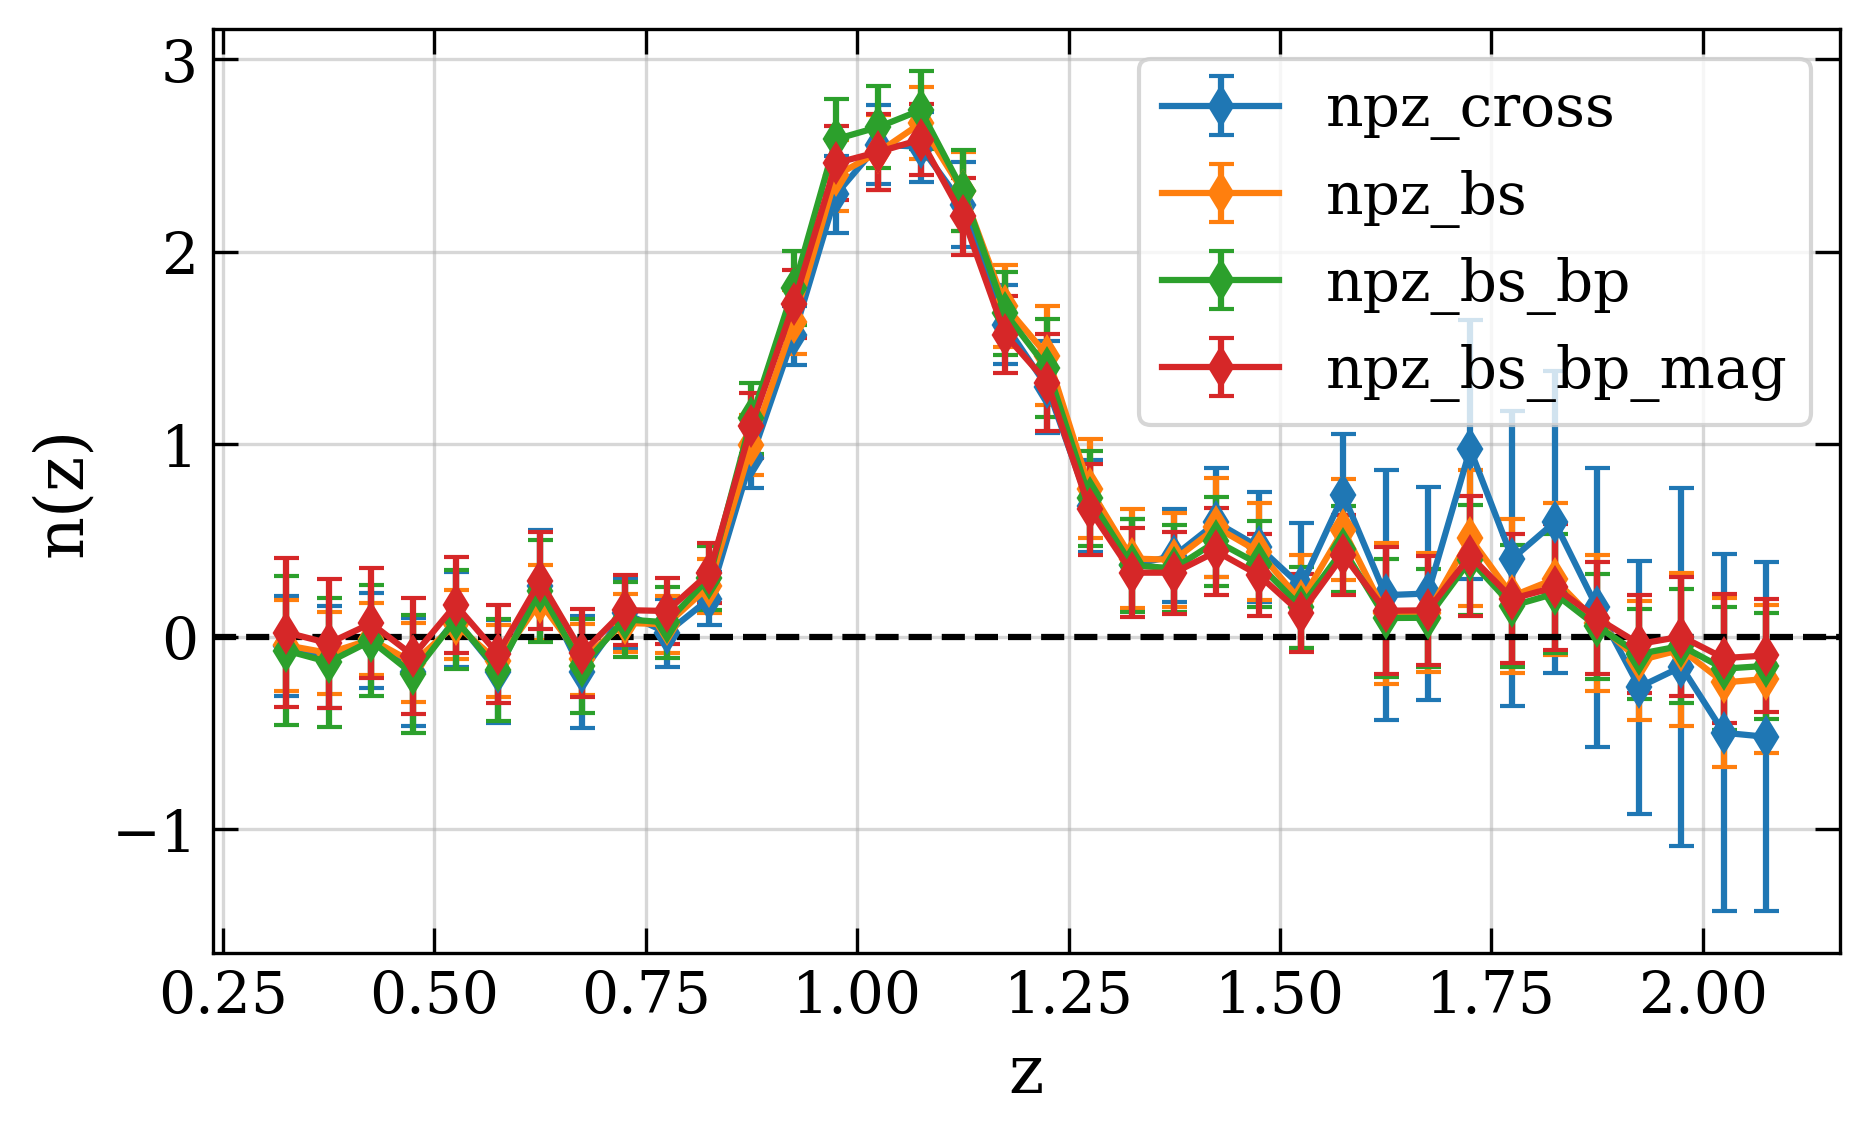

In [7]:
plt.figure(figsize=(7, 4))
tomo = 3
z = [data[f"{tomo}/{name}_z"] for name in names]
npz = [data[f"{tomo}/{name}"] for name in names]
npz_err = [data[f"{tomo}/{name}_err"] for name in names]

for i, name in enumerate(names):
    plt.errorbar(z[i], npz[i], npz_err[i], capsize=3, marker="d", label=name)
plt.legend(loc="upper right")
plt.grid(True)
plt.ylabel("n(z)")
plt.xlabel("z")
plt.axhline(0, color="black", linestyle="--")

In [27]:
## tests
tomo = 3
name = "npz_bs_bp_mag"
dir_splines = Path(f"{ROOT}/results/tests/splines_{scale_cut[0]}_{scale_cut[1]}")
dir_splines.mkdir(parents=True, exist_ok=True)
savefile = str(dir_splines / f"spl_{name}_{tomo}")
npz_arr = data[f"{tomo}/{name}"]
npz_arr_err = data[f"{tomo}/{name}_err"]
z_arr = data[f"{tomo}/{name}_z"]

for a0 in [0.05, 0.1, 0.5, 1, 10]:
    spl = spline.BayesianBSpline(zv=z_arr, n_knots=int(len(z_arr) // 2))
    spl.fit(
        npz_arr,
        npz_arr_err,
        n_tune=400,
        n_samples=1600,
        target_accept=0.99,
        prior_concentration=3,
        base_alpha=a0,
    )
    spl.save_model(savefile + f"_{a0}")

Initializing NUTS using jitter+adapt_diag...


Dirichlet alpha range: [0.050, 8.564]
Initial amplitude: 9.819
Non-zero NNLS coefficients: 14 / 20
[0.01786315 0.         0.         0.01642738 0.15026923 0.
 0.23758938 2.29897308 2.83799198 2.00873145 0.8277663  0.16648314
 0.44246725 0.21864454 0.14021457 0.436667   0.01927953 0.
 0.         0.        ]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 79 seconds.


...

Model saved:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_1.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_1_meta.pkl
Dirichlet alpha range: [10.000, 18.514]
Initial amplitude: 9.819
Non-zero NNLS coefficients: 14 / 20
[0.01786315 0.         0.         0.01642738 0.15026923 0.
 0.23758938 2.29897308 2.83799198 2.00873145 0.8277663  0.16648314
 0.44246725 0.21864454 0.14021457 0.436667   0.01927953 0.
 0.         0.        ]


Multiprocess sampling (4 chains in 4 jobs)
NUTS: [coeffs, amplitude]


Output()

Sampling 4 chains for 400 tune and 1_600 draw iterations (1_600 + 6_400 draws total) took 9 seconds.


Model fitting complete. Summary:               mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
coeffs[0]    0.034  0.010   0.017    0.053      0.000    0.000    8021.0   
coeffs[1]    0.034  0.010   0.016    0.053      0.000    0.000    6532.0   
coeffs[2]    0.029  0.009   0.014    0.045      0.000    0.000    7003.0   
coeffs[3]    0.026  0.008   0.013    0.041      0.000    0.000    6285.0   
coeffs[4]    0.027  0.007   0.014    0.040      0.000    0.000    7033.0   
coeffs[5]    0.022  0.006   0.011    0.034      0.000    0.000    5893.0   
coeffs[6]    0.031  0.008   0.017    0.046      0.000    0.000    5750.0   
coeffs[7]    0.137  0.014   0.111    0.164      0.000    0.000    5730.0   
coeffs[8]    0.197  0.018   0.165    0.231      0.000    0.000    6297.0   
coeffs[9]    0.124  0.016   0.093    0.152      0.000    0.000    6059.0   
coeffs[10]   0.054  0.012   0.031    0.075      0.000    0.000    6674.0   
coeffs[11]   0.033  0.009   0.016    0.049      0.000  

PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.05.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.05_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.1.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.1_meta.pkl
  - Posterior samples: 6400
PyMC model recreated from parameters
Model loaded from:
  - Trace: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.5.nc
  - Metadata: /global/cfs/cdirs/desicollab/users/jchdj/desi-y3-hsc/results/tests/splines_0.3_3/spl_npz_bs_bp_mag_3_0.5_meta.pkl
  - Posterior samples: 6400
PyMC 

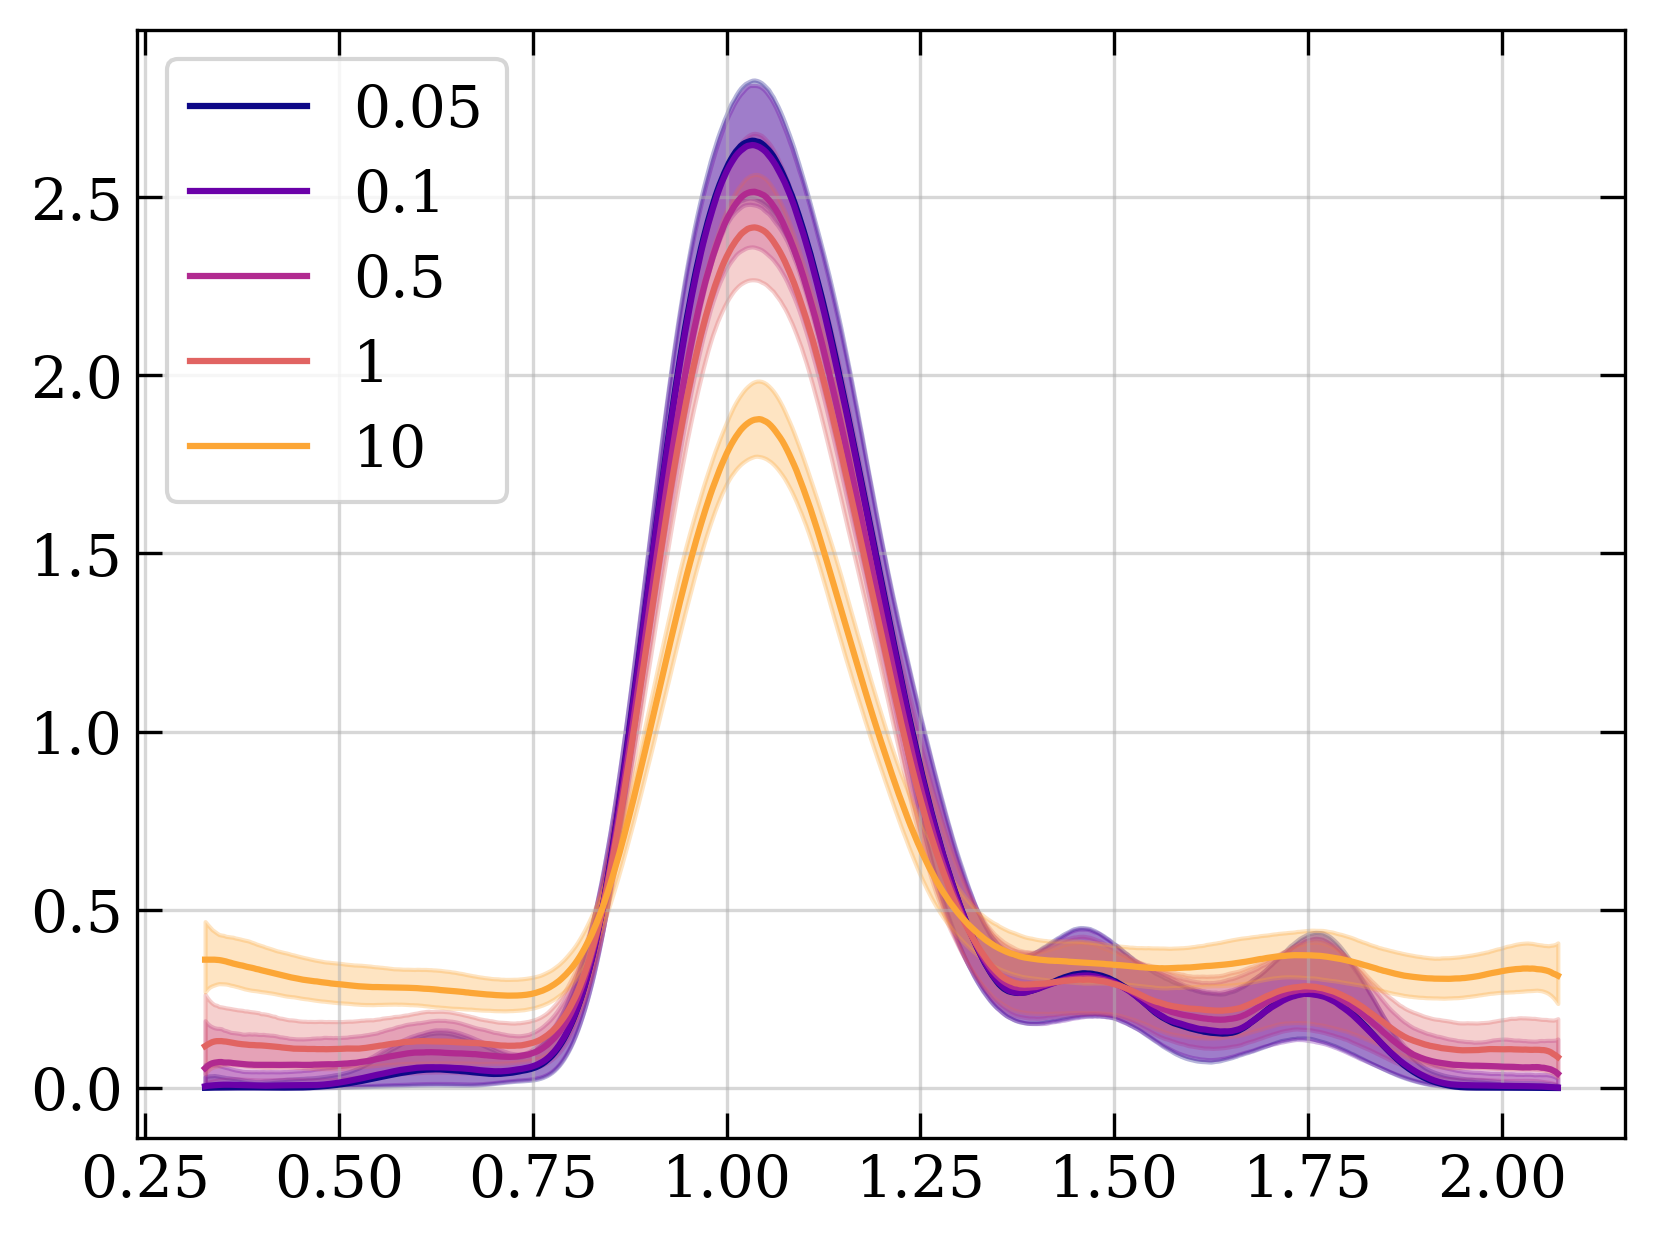

In [32]:
z_all = np.linspace(0, 3, 1000)
cmap = plt.get_cmap("plasma")

a0_range = [0.05, 0.1, 0.5, 1, 10]
spline_paths = [str(dir_splines / f"spl_{name}_{tomo}") + f"_{a0}" for a0 in a0_range]
for i, (spl_study_file, a_0) in enumerate(zip(spline_paths, a0_range)):
    color = cmap(i/len(spline_paths))
    spl_study = spline.BayesianBSpline.from_saved_model(spl_study_file)
    mask = (z_all <= spl_study.zv.max()) & (z_all >= spl_study.zv.min())
    z_eval = z_all[mask]

    n_eval_points = 200
    nz_samples = spl_study.get_samples(
        z_eval=z_eval, n_eval_points=n_eval_points
    )
    basis_eval = spl_study._create_evaluation_basis(z_eval)

    nz_median = np.percentile(nz_samples, 50, axis=0)
    norm_median = simpson(nz_median, z_eval)
    nz_samples_norm = nz_samples / simpson(nz_samples, z_eval, axis=1)[:, None]

    nz_median = np.percentile(nz_samples_norm, 50, axis=0)
    nz_mean = np.mean(nz_samples_norm, axis=0)
    nz_std = np.std(nz_samples_norm, axis=0)
    nz_lower = np.percentile(nz_samples_norm, 16, axis=0)
    nz_upper = np.percentile(nz_samples_norm, 84, axis=0)

    plt.plot(z_eval, nz_median, color=color, label=a_0)
    plt.fill_between(
        z_eval,
        nz_lower,
        nz_upper,
        color=color,
        alpha=0.3,
    )
    plt.legend(loc="upper left")

In [ ]:
importlib.reload(spline)
for sc in [[0.3, 3], [1, 5]]:
    data_file = f"{ROOT}/results/merged_res_norm_{sc[0]}_{sc[1]}_{version}.npz"
    print(f"Processing scale cut {sc}, data file: {data_file}, version: {version}")
    data = np.load(data_file)
    dir_splines = Path(f"{ROOT}/results/splines_{sc[0]}_{sc[1]}_{version}")
    if not dir_splines.exists():
        dir_splines.mkdir(parents=True)
    for i, name in enumerate(names):
        for tomo in range(1, 5):
            savefile = str(dir_splines / f"spl_{name}_{tomo}")
            npz_arr = data[f"{tomo}/{name}"]
            npz_arr_err = data[f"{tomo}/{name}_err"]
            z = data[f"{tomo}/{name}_z"]

            if Path(f"{savefile}.nc").exists():
                print(f"Skipping {savefile}, already exists")
                continue

            spl = spline.BayesianBSpline(zv=z, n_knots=int(len(z) // 2))
            spl.fit(
                npz_arr,
                npz_arr_err,
                n_tune=400,
                n_samples=1600,
                target_accept=0.99,
                prior_concentration=3,
                base_alpha=0.05,
            )
            spl.save_model(savefile)